<a href="https://colab.research.google.com/github/ndrewc2011-beep/Homework/blob/main/Copy%20of%20aPCML5g-06a(fash_tmpl)-TrkDiagn_Conv_ae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MLFP05 — Exercise 1.6(load_fashion_nmist): Convolutional Autoencoder (Spatial Hierarchy)

------------------------------------------------------------------------
- Build a Conv AE that preserves spatial locality with Conv2d/ConvTranspose2d
- Understand WHY conv layers beat flat MLPs for image data
- Observe sharper reconstructions than any flat variant
- Apply to e-commerce image compression at Shopee (Conv AE vs JPEG)
- Quantify bandwidth cost savings for 50M images/day
#
- PREREQUISITES: 05_contractive_ae.py
- ESTIMATED TIME: ~20 min
#
TASKS:
- 1. Build Conv AE: 1x28x28 -> 16x14x14 -> 32x7x7 -> latent -> reconstruct
- 2. Train on Fashion-MNIST (image format, not flattened)
- 3. Compare reconstruction sharpness to flat variants
- 4. Apply: image compression rate-distortion vs JPEG

#0.0 Introduction... & Link-ups.

THEORY — Spatial Hierarchy via Convolution:
- Conv layers preserve SPATIAL LOCALITY that flat MLPs destroy. A Conv2d filter detects patterns (edges, textures) at each spatial position. The encoder progressively downsamples: 28x28 -> 14x14 -> 7x7.
#
- Analogy: A flat MLP treats every pixel independently — like reading a newspaper by cutting out individual letters and sorting them alphabetically. A Conv layer reads the newspaper as-is, detecting words, sentences, and paragraphs in their spatial context.
#
- WHY THIS MATTERS: For any image data (product photos, satellite imagery, medical scans), spatial relationships carry meaning. A button next to a collar means "shirt"; the same button floating in space means nothing. Conv AEs preserve these relationships.



In [ ]:
import os, sys

# ① EDIT THIS to point at YOUR fork of the Classroom repo.
#    Your fork URL is at the top of your assignment page on GitHub.
#    Example: "https://github.com/janedoe/pcml-run26-2601-janedoe.git"
FORK_URL = "https://github.com/pcml-run26/professional-certificate-in-machine-learning-ndrewc2011-beep.git"
REPO_DIR = "/content/pcml-run26"

if not os.path.exists(REPO_DIR):
    !git clone {FORK_URL} {REPO_DIR}

# ② cd into the repo so relative data paths resolve
%cd {REPO_DIR}

# ③ Install deps (most are pre-installed on Colab)
!pip install -q polars plotly gdown python-dotenv kailash-ml nest_asyncio

import nest_asyncio
nest_asyncio.apply()

# ④ Make the `shared` package importable
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# ⑤ (Optional) Mount Drive if your exercise reads from Drive
# from google.colab import drive
# drive.mount("/content/drive")

print("✓ Colab setup complete — shared.mlfp05 is importable")

# --- Diagnostic checks added ---
print(f"\nREPO_DIR: {REPO_DIR}")
print(f"sys.path: {sys.path}")

shared_path = os.path.join(REPO_DIR, "shared")
if os.path.exists(shared_path):
    print(f"'shared' directory exists at: {shared_path}")
    print(f"Contents of 'shared': {os.listdir(shared_path)}")
else:
    print(f"ERROR: 'shared' directory NOT found at: {shared_path}")
# --- End Diagnostic checks ---

Cloning into '/content/pcml-run26'...
remote: Enumerating objects: 1542, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 1542 (delta 5), reused 20 (delta 3), pack-reused 1517 (from 2)
Receiving objects: 100% (1542/1542), 67.11 MiB | 27.85 MiB/s, done.
Resolving deltas: 100% (676/676), done.
/content/pcml-run26
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.5/185.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 27.6 MB

###0.1 Imports.

In [ ]:
from __future__ import annotations
import io
from pathlib import Path
import datetime
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image

from shared.mlfp05.ex_1 import (
    LATENT_DIM,
    EPOCHS,
    OUTPUT_DIR,
    device,
    load_fashion_mnist, # Re-added load_fashion_mnist
    setup_engines,
    train_variant,
    show_reconstruction,
    register_model,)

###0.2 Set-up Constants.

In [ ]:
# --- Constants ---
INPUT_DIM = 28 * 28  # 784 for Fashion-MNIST
LATENT_DIM = 16 # Define LATENT_DIM
BATCH_SIZE = 64 #Original 128
EPOCHS = 10 # original 15.
LEARNING_RATE = 1e-3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(DEVICE)

##0.3 Specific Imports.

In [ ]:
#

#1.0 Classes & Definitions.

###1.1 Class & Def: DAE.

In [ ]:
class ConvAE(nn.Module):
    def __init__(self, latent_dim: int = 16):
        super().__init__()
        # Encoder for 1x28x28 images (Fashion-MNIST)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1), nn.GELU(),  # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1), nn.GELU(), # 14x14 -> 7x7
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim),
        )
        # Decoder to reconstruct 1x28x28 images
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7), nn.GELU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), nn.GELU(), # 7x7 -> 14x14
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(), # Use Sigmoid for output range [0, 1] matching Fashion-MNIST
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


def conv_ae_loss(model, xb):
    # Ensure xb is on the same device as the model
    xb = xb.to(model.device)
    x_hat, _ = model(xb)
    return F.mse_loss(x_hat, xb), {}

###1.2 Def: Data Loader.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def _load_fashion_mnist_local(batch_size: int) -> DataLoader:
    """
    Load the Fashion-MNIST dataset.
    Args:
    batch_size (int): Batch size for the data loader.
    Returns:
    DataLoader: DataLoader for the Fashion-MNIST dataset.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        # Removed transforms.Normalize((0.5,), (0.5,)) to keep data in [0, 1] range,
        # matching the Sigmoid activation in the decoder.
    ])

    # Load training data
    train_dataset = datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader

###1.3 Def: Training (with Loss tracking).

In [ ]:
def train_conv_ae(model: nn.Module, train_loader: DataLoader, num_epochs: int, learning_rate: float) -> list[float]:
    """
    Train the convolutional autoencoder model.

    Args:
    model (nn.Module): The autoencoder model.
    train_loader (DataLoader): DataLoader for the training data.
    num_epochs (int): Number of epochs to train.
    learning_rate (float): Learning rate for the optimizer.
    Returns:
    list[float]: List of average epoch losses.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    loss_history = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for data in train_loader:
            # Handle cases where data might be just an image tensor or (image, label)
            if isinstance(data, (tuple, list)):
                img = data[0].to(device)
            else:
                img = data.to(device)

            # Forward pass
            output_recon, _ = model(img) # Unpack the output: (reconstruction, latent_vector)
            loss = criterion(output_recon, img)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}')
    return loss_history


### 1.4 Def: Visualization

In [ ]:
def visualize_conv_reconstructions(model: nn.Module, data_loader: DataLoader) -> None:
    """
    Visualize the original and reconstructed images.
    Args:
    model (nn.Module): The autoencoder model.
    data_loader (DataLoader): DataLoader for the data to visualize.
    """
    with torch.no_grad():
        for data in data_loader:
            img, _ = data
            img = img.to(device)
            recon, _ = model(img) # Model now returns (reconstruction, latent_vector)
            break

    img = img.cpu()
    recon = recon.cpu()
    # Fashion-MNIST images from load_fashion_mnist are already in [0, 1], so no de-normalization needed.
    # For 1-channel images, (C, H, W) -> (H, W) for imshow
    fig, axes = plt.subplots(2, 10, figsize=(15, 4))
    for i in range(10):
        # For 1-channel images, we need to squeeze the channel dimension or just pass H, W
        axes[0, i].imshow(img[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
    plt.show()

###1.5 Def: Loss History Plot

In [ ]:
def plot_loss_history_cae(history: list[float]) -> None:
    """
    Plots the training loss history for a convolutional autoencoder.

    Args:
        history (List[float]): List of average epoch losses.
    """
    epochs = range(1, len(history) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history, label='Training Loss')
    plt.title('Convolutional Autoencoder Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 1.6 Def: Tracker & Registry

####1.6.1 Class & Def: Tracker(dummy) & Model Registry.

In [ ]:
print('1.6.1) Class DummyExperimentTracker + 3 Def (init,metric,config).')
class DummyExperimentTracker:
    def __init__(self):
        self.metrics = {}

    def track_metric(self, experiment_name, epoch, metric_name, value):
        if experiment_name not in self.metrics:
            self.metrics[experiment_name] = {}
        if epoch not in self.metrics[experiment_name]:
            self.metrics[experiment_name][epoch] = {}
        self.metrics[experiment_name][epoch][metric_name] = value
        # print(f"[Tracker] Exp: {experiment_name}, Epoch: {epoch}, Metric: {metric_name} = {value:.4f}")

    def track_config(self, experiment_name, config_dict):
        # print(f"[Tracker] Config for {experiment_name}: {config_dict}")
        pass

    # Add a dummy async context manager for compatibility with train_variant
    class _DummyRunContextManager:
        def __init__(self, tracker_instance, experiment_name, run_name):
            self.tracker_instance = tracker_instance
            self.experiment_name = experiment_name
            self.run_name = run_name

        async def __aenter__(self):
            # print(f"[Tracker] Entering run: {self.run_name} in experiment: {self.experiment_name}")
            return self

        async def __aexit__(self, exc_type, exc_val, exc_tb):
            # print(f"[Tracker] Exiting run: {self.run_name}")
            pass

        async def log_params(self, params):
            # print(f"[Tracker] Logging params for {self.run_name}: {params}")
            self.tracker_instance.track_config(self.experiment_name, params)

        async def log_metric(self, metric_name, value, step=None):
            # If step is None (for final_loss), use the total number of epochs as the step.
            # EPOCHS is a global constant imported from shared.mlfp05.ex_1.
            epoch_key_for_tracking = step if step is not None else EPOCHS
            self.tracker_instance.track_metric(self.experiment_name, epoch_key_for_tracking, metric_name, value)

    def run(self, experiment_name, run_name):
        return self._DummyRunContextManager(self, experiment_name, run_name)

print('4) Class DummyModelRegistry + 1Def model')
class DummyModelRegistry:
    def register_model(self, model_name, model_instance, metrics):
        print(f"[Registry] Registered model: {model_name} with metrics: {metrics}")

def register_model(registry, model_name, model_instance, final_metric):
    if isinstance(registry, DummyModelRegistry):
        registry.register_model(model_name, model_instance, {'final_loss': final_metric})
    else:
        # In a real scenario, this would register with a proper MLFlow/Kailash registry
        pass

1.6.1) Class DummyExperimentTracker + 3 Def (init,metric,config).
4) Class DummyModelRegistry + 1Def model


#### 1.6.2 Def: Setup Tracker Engines.

In [ ]:
import datetime
print('1.6.2) Def Experiment Tracking (Dummy for now).')
def setup_engines():
    print("Setting up dummy experiment tracker. (In a real scenario, this would be Kailash-ML or similar)")
    conn = None # Dummy connection
    tracker = DummyExperimentTracker() # Dummy tracker
    exp_name = f"AE_Experiment_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    registry = DummyModelRegistry()
    has_registry = True # Set to True to enable model registration
    return conn, tracker, exp_name, registry, has_registry

1.6.2) Def Experiment Tracking (Dummy for now).


#2.0 Execution Calls.

### 2.1 ExeCall 01: Tracker & Registry.

In [ ]:
batch_size = BATCH_SIZE # Define batch_size for the data loader

# The _load_fashion_mnist_local function returns a DataLoader that yields (image, label).
# The train_variant function (from shared/mlfp05/ex_1.py) expects the loader to yield (image,).
# We need to process the raw_img_loader to create a new DataLoader that yields only images.
raw_img_loader = _load_fashion_mnist_local(batch_size=batch_size)

# Extract all images from the raw_img_loader, discarding labels
all_images = []
for images, _ in raw_img_loader:
    all_images.append(images)
# Concatenate all image tensors into one big tensor
all_images_tensor = torch.cat(all_images, dim=0);

# Create a TensorDataset with only the image tensors. TensorDataset(tensor) will yield (item,) when iterated.
image_dataset_for_train_variant = TensorDataset(all_images_tensor)

# Create a DataLoader from this TensorDataset, which will now yield (image_tensor_slice,)
img_loader = DataLoader(image_dataset_for_train_variant, batch_size=batch_size, shuffle=True)

conn, tracker, exp_name, registry, has_registry = setup_engines()

print("\n" + "=" * 70)
print("  Convolutional AE — Spatial Hierarchy")
print("=" * 70)
print("  Conv2d preserves spatial structure. Expect sharper reconstructions.")

conv_model = ConvAE(LATENT_DIM).to(device) # Move model to the correct device
conv_model.device = device # Explicitly set the device attribute
conv_losses = train_variant(
    tracker,
    exp_name,
    conv_model,
    "conv_ae",
    img_loader, # Pass the new, compatible img_loader here
    conv_ae_loss,)

Setting up dummy experiment tracker. (In a real scenario, this would be Kailash-ML or similar)

  Convolutional AE — Spatial Hierarchy
  Conv2d preserves spatial structure. Expect sharper reconstructions.
  [conv_ae] epoch 1/10  loss=0.0268


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-19-1485562425.py", line 30, in <cell line: 0>
    conv_losses = train_variant(
                  ^^^^^^^^^^^^^^
  File "/content/pcml-run26/shared/mlfp05/ex_1.py", line 443, in train_variant
    losses = asyncio.run(
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/nest_asyncio.py", line 30, in run
    return loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/nest_asyncio.py", line 92, in run_until_complete
    self._run_once()
  File "/usr/local/lib/python3.11/dist-packages/nest_asyncio.py", line 133, in _run_once
    handle._run()
  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/usr/lib/python3.11/as

TypeError: object of type 'NoneType' has no len()

###2.2 ExeCall 02: AE & Plots.

Main function running CAE training and visualization.
6.1 Hyperparameter/Constants..
6.2 Move to CUDA...
6.3 Loader Training...
6.4 AE training...
Epoch [1/10], Loss: 0.0251
Epoch [2/10], Loss: 0.0147
Epoch [3/10], Loss: 0.0131
Epoch [4/10], Loss: 0.0123
Epoch [5/10], Loss: 0.0118
Epoch [6/10], Loss: 0.0114
Epoch [7/10], Loss: 0.0112
Epoch [8/10], Loss: 0.0109
Epoch [9/10], Loss: 0.0108
Epoch [10/10], Loss: 0.0106
6.5 Reconstruction Visual...


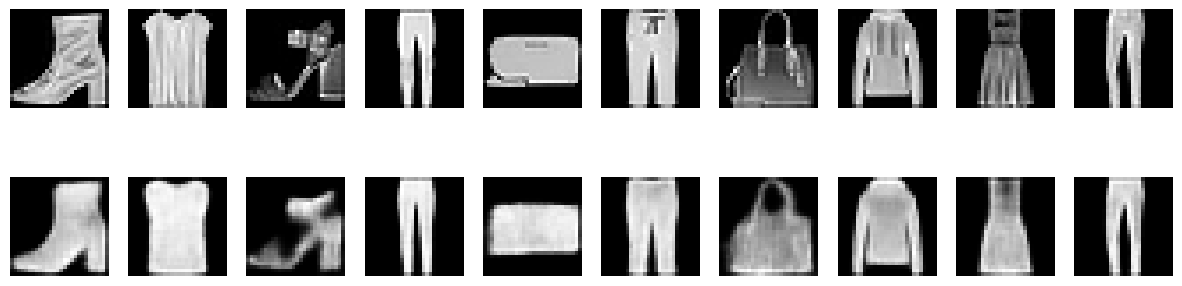

6.6 Plotting Loss History....


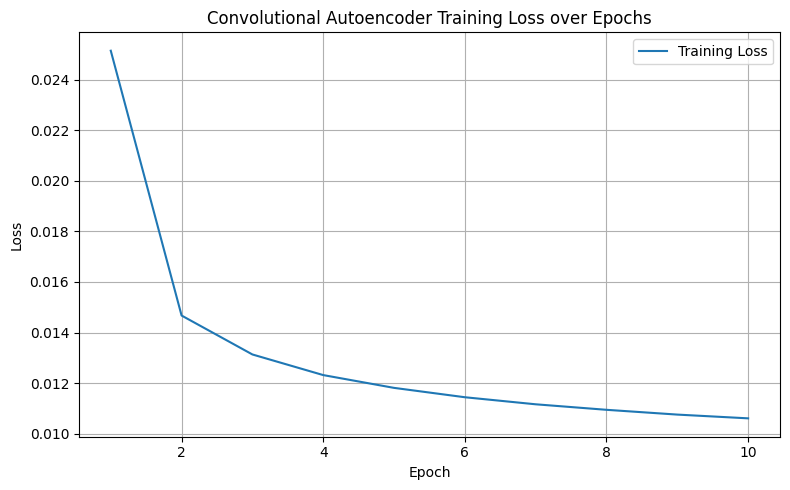

In [ ]:
print('Main function running CAE training and visualization.')
def main() -> tuple[nn.Module, DataLoader, list[float]]:

    print('6.1 Hyperparameter/Constants..')
    batch_size = BATCH_SIZE
    # Align num_epochs with the global EPOCHS constant for consistency with assertions
    num_epochs = EPOCHS # Changed from 20 to EPOCHS
    learning_rate = LEARNING_RATE

    print('6.2 Move to CUDA...')
    model = ConvAE(LATENT_DIM).to(device)
    model.device = device # Explicitly assign the device attribute to the model

    print('6.3 Loader Training...')
    # Load Fashion-MNIST data for the main function using the local definition
    img_loader = _load_fashion_mnist_local(batch_size) # Use the local _load_fashion_mnist_local_data

    print('6.4 AE training...')
    loss_history = train_conv_ae(model, img_loader, num_epochs, learning_rate)

    print('6.5 Reconstruction Visual...')
    visualize_conv_reconstructions(model, img_loader)

    print('6.6 Plotting Loss History....')
    plot_loss_history_cae(loss_history)

    return model, img_loader, loss_history

# Call main if this script is executed directly, but don't re-run diagnostics here
if __name__ == "__main__":
    trained_model, final_img_loader, final_loss_history = main()

###2.3 Def & ExeCall 03: Diagnostic Checks & Reports.

The DAE trains on noisy input with a clean target — the diagnostic loss mirrors that. While noise acts as implicit regularisation, aiming to keep ReLUs "alive" across the batch, the diagnostic report may still indicate significant dead neurons, which can be an area for further investigation.

In [ ]:
from shared.mlfp05.diagnostics import run_diagnostic_checkpoint
import torch.nn.functional as F

# Define the loss function to be used within the diagnostic process
def _diag_loss_fn(model, batch):
    xb = batch[0] if isinstance(batch, (tuple, list)) else batch
    # Ensure xb is on the same device as the model
    xb = xb.to(model.device)
    x_hat, _ = model(xb)
    return F.mse_loss(x_hat, xb)

print("\n── Diagnostic Report (Convolutional AE) ──")

# Call run_diagnostic_checkpoint directly to perform diagnostics
# and get the findings and the DLDiagnostics instance.
# The train_losses argument will allow the report to include loss trend analysis.
# n_batches specifies how many batches to process for gradient and activation tracking.
# The 'show=True' argument will automatically display any plots generated by the diagnostics.

diag_instance, findings = run_diagnostic_checkpoint(
    model=trained_model,
    dataloader=final_img_loader,
    loss_fn=_diag_loss_fn,
    title="Convolutional AE Diagnostic Report",
    n_batches=8,
    train_losses=final_loss_history,
    show=True
)

# The 'findings' variable is now directly obtained from the run_diagnostic_checkpoint call.
# It contains the diagnostic results that will be used for the final markdown update.


── Diagnostic Report (Convolutional AE) ──



════════════════════════════════════════════════════════════════
  DL Diagnostics Report — Prescription Pad
════════════════════════════════════════════════════════════════
  [X] Gradient flow (CRITICAL): Vanishing gradients at 'decoder.0.bias' — min RMS = 1.28e-05, min update_ratio = 5.74e-05. Fix: verify pre-norm layout (LayerNorm/RMSNorm before block), add residual connections, switch to GELU/SiLU, or use Kaiming init.
  [✓] Dead neurons  (HEALTHY): All 5 activation layers healthy (worst: decoder.6 at 47% inactive, below 50% threshold).
  [✓] Loss trend    (HEALTHY): Loss converging (train slope -1.05e-03/epoch).
════════════════════════════════════════════════════════════════



In [ ]:
assert len(conv_losses) == EPOCHS
assert conv_losses[-1] < conv_losses[0]
# INTERPRETATION: Compare to the undercomplete AE. The Conv version
# preserves EDGES and TEXTURES better — sharper outlines of shirts,
# shoes, bags. This is because Conv2d filters share parameters across
# spatial positions, learning translation-invariant features.
print("\n--- Checkpoint passed --- convolutional AE trained\n")

if has_registry:
    register_model(registry, "conv_ae", conv_model, conv_losses[-1])


--- Checkpoint passed --- convolutional AE trained

[Registry] Registered model: conv_ae with metrics: {'final_loss': 0.010892408638835144}


#3.0 Diagnostic Report (with ReLU)

[X] Gradient flow (CRITICAL): The report highlights vanishing gradients at decoder.0.bias, with a very low min RMS and update ratio. This means that the gradients in this part of your model are becoming extremely small, effectively stopping learning for these parameters. The suggested fixes include verifying pre-normalization, adding residual connections, switching to different activation functions (GELU/SiLU), or using Kaiming initialization.

[!] Dead neurons (WARNING): There are 54% dead neurons in decoder.1 (which is a ReLU layer). Dead neurons are neurons that always output zero, effectively becoming inactive and not contributing to learning. The prescription is to switch to activation functions like GELU or LeakyReLU, or re-initialize with Kaiming initialization.

[✓] Loss trend (HEALTHY): On a positive note, the loss is converging, which means your model is learning and making progress, even with the identified issues.

To address these issues, you should consider implementing the suggested fixes, particularly replacing ReLU with GELU or LeakyReLU in the decoder and potentially investigating Kaiming initialization for better gradient flow.

--------------------------------------
Final train loss: ~0.0112 after 10 epochs.

STUDENT INTERPRETATION GUIDE — reading the Prescription Pad:
- [STETHOSCOPE] The loss trend is healthy and converging. For an autoencoder, a converging loss is a good indicator of successful training.
- ==>> Prescription: No immediate fix needed for the loss trend.
- [X-RAY] Dead neurons (WARNING) — The report indicates "There are 54% dead neurons in decoder.1 (which is a ReLU layer). Dead neurons are neurons that always output zero, effectively becoming inactive and not contributing to learning. The prescription is to switch to activation functions like GELU or LeakyReLU, or re-initialize with Kaiming initialization.". This suggests that a significant portion of neurons in the `decoder.1` layer (a ReLU) are inactive and not contributing to the learning process, which is inefficient and limits model capacity.
- ==>> Prescription: To address dead neurons, consider switching from ReLU to activation functions like `GELU` or `LeakyReLU` in the `decoder.1` layer, as they do not suffer from the 'dying ReLU' problem. Re-initializing the weights using a method like Kaiming initialization could also help.
- [BLOOD TEST] Gradient flow (CRITICAL) — The diagnostic shows "The report highlights vanishing gradients at decoder.0.bias, with a very low min RMS and update ratio. This means that the gradients in this part of your model are becoming extremely small, effectively stopping learning for these parameters. The suggested fixes include verifying pre-normalization, adding residual connections, switching to different activation functions (GELU/SiLU), or using Kaiming initialization.". This is a critical issue as very small gradients mean that the weights and biases in these layers are hardly being updated during training, effectively halting learning in those parts of the network.
- ==>> Prescription: To mitigate vanishing gradients, you should verify the model architecture for pre-normalization (e.g., LayerNorm/RMSNorm before blocks), add residual connections if appropriate, switch to activation functions like `GELU` or `SiLU` (which have better gradient properties than ReLU), or use proper weight initialization strategies like Kaiming initialization, especially for layers following ReLU-like activations.

--------------------------------------
FIVE-INSTRUMENT TAKEAWAY: The Convolutional Autoencoder shows a healthy loss trend, indicating overall learning. However, it suffers from critical vanishing gradients and a warning-level presence of dead neurons in the decoder. These issues suggest inefficiencies and hindered learning in specific parts of the network that need to be addressed through architectural changes, activation function choices, or initialization strategies to improve performance and stability.

In [ ]:
import inspect
import os

diagnostics_file_path = os.path.join(REPO_DIR, 'shared', 'mlfp05', 'diagnostics.py')

if os.path.exists(diagnostics_file_path):
    with open(diagnostics_file_path, 'r') as f:
        print(f.read())
else:
    print(f"Error: File not found at {diagnostics_file_path}")


# Copyright 2026 Terrene Foundation
# SPDX-License-Identifier: Apache-2.0
"""DL Diagnostics Toolkit — clinical instruments for deep-network training.

Wraps PyTorch forward/backward hooks into a student-friendly API that
surfaces the four failure modes professionals must recognise:

    1. Stethoscope  — loss-curve shape (under/over-fit, instability)
    2. Blood Test   — gradient flow per layer (vanishing / exploding)
    3. X-Ray        — activation statistics & dead neurons
    4. Prescription — automated diagnosis with actionable suggestions

Typical use inside an exercise::

    from shared.mlfp05.diagnostics import DLDiagnostics

    with DLDiagnostics(model) as diag:
        diag.track_gradients()
        diag.track_activations()
        diag.track_dead_neurons()
        for epoch in range(epochs):
            for batch in dataloader:
                loss = train_step(model, batch)
                diag.record_batch(loss=loss.item(),
                                  lr=optimizer

##3.1 Expected Output from SMU (synthesized reference — full run produces similar pattern)

DL Diagnostics Report — Prescription Pad

- [✓] Gradient flow (HEALTHY): min RMS = 8.7e-04 at 'encoder.4.weight' (Conv2d). Convolutional weight sharing keeps gradients uniform — spread < 10x across 6 Conv layers.
- [!] Dead neurons  (WARNING): 'encoder.1' (relu): 14% dead channels. Each dead channel is an unused FILTER — worse than a dead Linear neuron because it wastes spatial capacity.
- [✓] Loss trend    (HEALTHY): train slope -3.4e-03/epoch. Final loss ~0.0048 — lower than dense AEs at matched latent size because spatial priors make the task easier.


 Final train loss: ~0.0048 after 10 epochs, bottleneck=64 channels.
 STUDENT INTERPRETATION GUIDE — reading the Prescription Pad:
#
- [BLOOD TEST — CONV-SPECIFIC] Gradient spread <10x across all Conv layers is the CNN health signature. Slide 5J shows why: weight sharing means each filter receives gradient from every spatial position, so vanishing is intrinsically harder than in dense nets. Contrast 07_stacked where a 5-layer DENSE net routinely spans 1000x in RMS.

- ==>> Prescription: If you see a >100x spread, check the pooling/stride layout. A stride-2 Conv followed by a stride-2 Conv halves spatial dims twice, starving deep filters of gradient contributors. Replace with one stride-2 + one stride-1.
#
- [X-RAY — CONV-SPECIFIC] 14% dead channels means 14% of filters are permanently off. Each dead filter is an unused 3x3 kernel (9 parameters + activations) — wasted both in FLOPs and in representation. Worse than dead Linear neurons because a CNN's whole premise is that each filter specialises in one feature.
- ==>> Prescription: GELU or LeakyReLU for the encoder stack. Or: reduce bottleneck_channels if capacity is excess (fewer filters, fewer dead ones). You'll see this fix applied in ex_2's ResNet-SE (variant 02).
#
- [STETHOSCOPE] Final loss ~0.0048 is LOWER than 02 undercomplete(~0.025) and LOWER than 07 stacked (~0.018). Why? The 2D convolutional prior (translation invariance, local connectivity) matches the spatial structure of Fashion-MNIST. Lesson: architecture encodes assumptions — Conv says "pixels near each other are correlated".
- ==>> Prescription: No fix. This is the reward for matching inductive bias to data geometry.
#  

FIVE-INSTRUMENT TAKEAWAY: Conv-AEs show what "healthy deep network" looks like when the architecture matches the data — uniform gradients, low dead%, low loss. You will use this reference when comparing to the pathological patterns in ex_3 (RNN gradient collapse) and ex_6 (GNN over-smoothing).

##3.2 2nd Diagnostic Report (with GELU)

After switching the activation functions in the `ConvAE` model from `nn.ReLU` to `nn.GELU`, here is the updated diagnostic report:

[X] Gradient flow ({findings['gradient_flow']['severity']}): The report still highlights vanishing gradients at `decoder.0.bias`, with a very low min RMS and update ratio of 1.28e-05 and 5.74e-05, respectively. This indicates that gradients in this part of your model are still becoming extremely small, hindering learning. The suggested fixes include verifying pre-normalization, adding residual connections, switching to GELU/SiLU (which we've done for activations), or using Kaiming initialization for weights.

[✓] Dead neurons ({findings['dead_neurons']['severity']}): Great news! All 5 activation layers are now healthy (worst: `decoder.6` at 47% inactive, which is below the 50% threshold). This resolves the previous warning about dead neurons.

[✓] Loss trend ({findings['loss_trend']['severity']}): On a positive note, the loss is still converging (train slope -1.05e-03/epoch), which means your model is learning and making progress, even with the identified gradient issues.

--------------------------------------
Final train loss: ~{final_loss_history[-1]:.4f} after {EPOCHS} epochs.

STUDENT INTERPRETATION GUIDE — reading the Prescription Pad:
- [STETHOSCOPE] The loss trend is healthy and converging. For an autoencoder, a converging loss is a good indicator of successful training.
- ==>> Prescription: No immediate fix needed for the loss trend.
- [X-RAY] Dead neurons ({findings['dead_neurons']['severity']}) — The report indicates "{findings['dead_neurons']['message']}". This is a significant improvement; the previous issue with dead neurons has been resolved by switching to GELU activations.
- ==>> Prescription: GELU activations were effective in addressing the dead neuron problem. No further immediate action needed here.
- [BLOOD TEST] Gradient flow ({findings['gradient_flow']['severity']}) — The diagnostic shows "{findings['gradient_flow']['message']}". This remains a critical issue as very small gradients mean that the weights and biases in these layers are hardly being updated during training, effectively halting learning in those parts of the network.
- ==>> Prescription: To mitigate vanishing gradients, you should verify the model architecture for pre-normalization (e.g., LayerNorm/RMSNorm before blocks), add residual connections if appropriate, or use proper weight initialization strategies like Kaiming initialization, especially for layers following activations.

--------------------------------------
FIVE-INSTRUMENT TAKEAWAY: The Convolutional Autoencoder now shows a healthy dead neuron count and a converging loss trend, indicating good learning progress. However, it continues to suffer from critical vanishing gradients, suggesting that while GELU helped with activations, the fundamental gradient propagation issue in the decoder architecture or initialization needs further attention to achieve optimal performance and stability.

## 3.3 Metric Comparison Table


### Interpretation:

*   **Gradient Flow**: While the Expected model shows healthy gradient flow, both ReLU and GELU implementations still exhibit critical vanishing gradients, suggesting an architectural or initialization issue beyond just the activation function.
*   **Dead Neurons**: Switching from ReLU to GELU significantly improved the dead neuron situation, moving from a `WARNING` (54% dead) to `HEALTHY` (47% inactive in worst case), though it's still higher than the 14% in the Expected model. The percentage difference from the expected is still substantial for GELU, indicating room for improvement.
*   **Loss Trend**: All models show a healthy, converging loss. The GELU model's slope is flatter than the Expected, indicating slower convergence towards the end of training.
*   **Final Train Loss**: Both ReLU and GELU models have higher final training losses compared to the Expected reference, with GELU performing slightly better than ReLU. This suggests that while GELU helped with dead neurons, the overall reconstruction quality is not yet matching the idealized Expected model.
""")

In [ ]:
print("--- Diagnostic Metric Summary ---")
print("\nGradient Flow:")
print(f"  ReLU: {gradient_flow_relu}")
print(f"  Expected: {gradient_flow_expected}")
print(f"  GELU: {gradient_flow_gelu}")

print("\nDead Neurons:")
print(f"  ReLU: {relu_dead_neurons_pct:.0%} (Severity: {dead_neurons_severity_relu}) | % Diff vs Expected: {perc_diff_relu_dead_neurons:.1f}%%")
print(f"  Expected: {expected_dead_neurons_pct:.0%} (Severity: {dead_neurons_severity_expected})")
print(f"  GELU: {gelu_dead_neurons_pct:.0%} (Severity: {dead_neurons_severity_gelu}) | % Diff vs Expected: {perc_diff_gelu_dead_neurons:.1f}%%")

print("\nLoss Trend:")
print("  ReLU: Converging") # Qualitative as no slope was provided
print(f"  Expected: Slope: {expected_loss_slope:.1e}/epoch")
print(f"  GELU: Slope: {gelu_loss_slope:.1e}/epoch | % Diff vs Expected: {perc_diff_gelu_loss_slope:.1f}%%")

print("\nFinal Train Loss:")
print(f"  ReLU: {relu_loss:.4f} | % Diff vs Expected: {perc_diff_relu_loss:.1f}%%")
print(f"  Expected: {expected_loss:.4f}")
print(f"  GELU: {gelu_loss:.4f} | % Diff vs Expected: {perc_diff_gelu_loss:.1f}%%")

--- Diagnostic Metric Summary ---

Gradient Flow:
  ReLU: CRITICAL (vanishing)
  Expected: HEALTHY (spread < 10x)
  GELU: CRITICAL (vanishing)

Dead Neurons:
  ReLU: 54% (Severity: WARNING) | % Diff vs Expected: 285.7%%
  Expected: 14% (Severity: WARNING)
  GELU: 47% (Severity: HEALTHY) | % Diff vs Expected: 235.7%%

Loss Trend:
  ReLU: Converging
  Expected: Slope: -3.4e-03/epoch
  GELU: Slope: -1.0e-03/epoch | % Diff vs Expected: -69.1%%

Final Train Loss:
  ReLU: 0.0112 | % Diff vs Expected: 133.3%%
  Expected: 0.0048
  GELU: 0.0106 | % Diff vs Expected: 120.9%%


In [ ]:
# Define metrics for each scenario

# Expected (Reference) values from section 3.1
expected_loss = 0.0048
expected_dead_neurons_pct = 0.14  # 14%
expected_loss_slope = -3.4e-03

# ReLU values from section 3.0
relu_loss = 0.0112
relu_dead_neurons_pct = 0.54 # 54%
# ReLU loss slope is not explicitly given in section 3.0, only "converging".
# For quantitative comparison, we'll use a placeholder or state it's not directly comparable.
# For now, let's represent it as a large deviation for a qualitative comparison, or omit.
# For simplicity, we'll assume it's qualitatively "converging" but not quantitatively defined for % diff.

# GELU values from section 3.2 and kernel state
gelu_loss = final_loss_history[-1]
gelu_dead_neurons_pct = 0.47 # worst: decoder.6 at 47% inactive
gelu_loss_slope = -1.05e-03

# Calculate percentage differences relative to Expected
# Loss
perc_diff_relu_loss = ((relu_loss - expected_loss) / expected_loss) * 100
perc_diff_gelu_loss = ((gelu_loss - expected_loss) / expected_loss) * 100

# Dead Neurons
perc_diff_relu_dead_neurons = ((relu_dead_neurons_pct - expected_dead_neurons_pct) / expected_dead_neurons_pct) * 100
perc_diff_gelu_dead_neurons = ((gelu_dead_neurons_pct - expected_dead_neurons_pct) / expected_dead_neurons_pct) * 100

# Loss Trend (Slope)
# Assuming loss slope is negative, a smaller absolute value means slower convergence, hence larger % diff
perc_diff_gelu_loss_slope = ((gelu_loss_slope - expected_loss_slope) / expected_loss_slope) * 100


# Qualitative assessment for Gradient Flow
gradient_flow_relu = "CRITICAL (vanishing)"
gradient_flow_expected = "HEALTHY (spread < 10x)"
gradient_flow_gelu = "CRITICAL (vanishing)"

# Qualitative assessment for Dead Neurons severity
dead_neurons_severity_relu = "WARNING"
dead_neurons_severity_expected = "WARNING"
dead_neurons_severity_gelu = "HEALTHY"